In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
data = pd.read_csv('solver_data.csv')
V0s = np.sort(data['V0'].unique())
dTs = np.sort(data['dT'].unique())
data

,diverged,converged,steps,dT,C0,V,R,f1,f2,V0
0,True,False,142,1.0,3.5,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000010
1,False,False,1000,1.0,3.5,0.008901,-3.378940e-07,-5.551120e-16,-2.117580e-22,0.000013
2,False,True,386,1.0,3.5,0.002067,7.132760e-07,0.000000e+00,-1.058790e-21,0.000016
3,False,True,364,1.0,3.5,0.000011,-9.625020e-06,0.000000e+00,5.082200e-21,0.000020
4,False,True,408,1.0,3.5,0.000011,-9.625020e-06,0.000000e+00,5.082200e-21,0.000025
...,...,...,...,...,...,...,...,...,...,...
6034,True,False,38,50.0,3.5,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.981070
6035,True,False,23,50.0,3.5,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,5.011870
6036,True,False,38,50.0,3.5,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.309570
6037,True,False,47,50.0,3.5,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.943280


In [4]:
approx_data = pd.read_csv('approx_data.csv')
approx_data.head()

,dT,C0,V,R
0,1.0,3.5,0.000011,0.000010
1,1.5,3.5,0.000031,0.000006
2,2.0,3.5,0.000063,0.000004
3,2.5,3.5,0.000109,0.000003
4,3.0,3.5,0.000173,0.000003


In [5]:
grids = {col: data[col].to_numpy().reshape([len(dTs), len(V0s)]).T[::-1] for col in data.columns} # top row should be highest V0 value
grids['f'] = np.abs(grids['f1']) + np.abs(grids['f2'])
grids['f_log'] = np.full(shape=[len(V0s), len(dTs)], fill_value=np.nan)
np.log10(grids['f'], out=grids['f_log'], where=~grids['diverged'])

approx_v = approx_data['V'].to_numpy()[np.newaxis, :]
percent_error = 100 * np.abs(grids['V'] -  approx_v) / approx_v
percent_error[grids['diverged']] = np.nan

In [6]:
np.sum(grids['converged']) / len(data)

np.float64(0.013578407021029972)

In [7]:
np.sum(grids['diverged']) / len(data)

np.float64(0.8168570955456201)

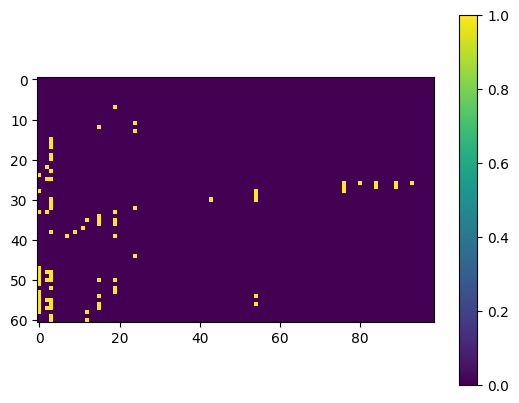

In [8]:
plt.imshow(grids['converged']==True)
plt.colorbar()

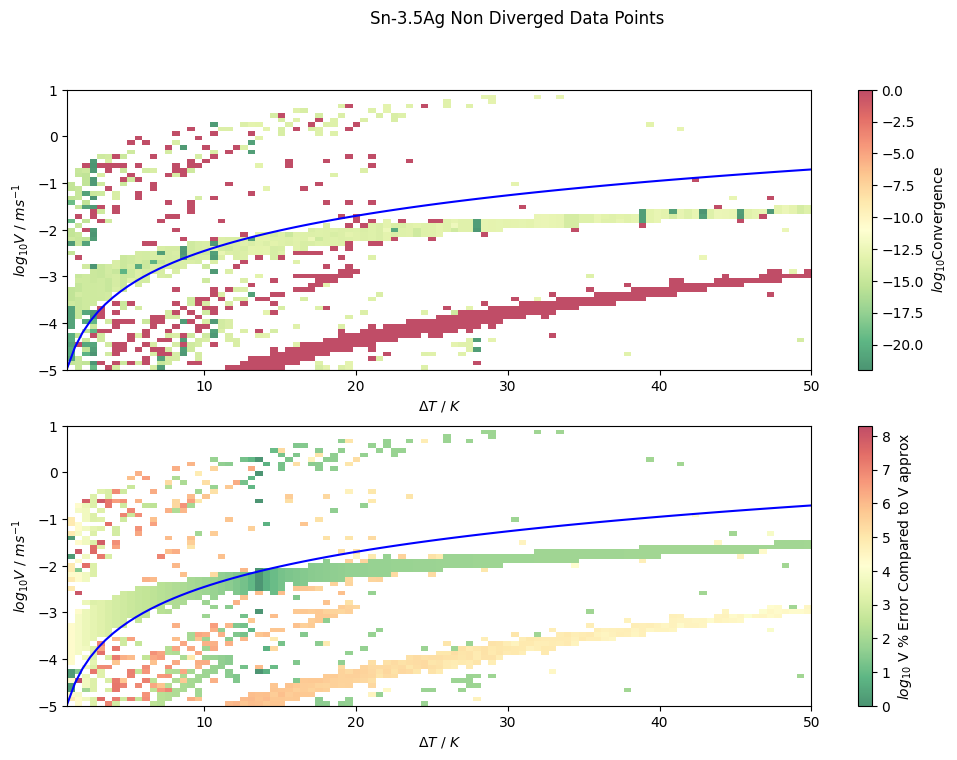

In [14]:
fig, axes = plt.subplots(nrows=2, figsize=(12,8))
fig.suptitle('Sn-3.5Ag Non Diverged Data Points')

for ax in axes:
	ax.plot(approx_data['dT'], np.log10(approx_data['V']), color='blue')
	ax.set_xlabel(r'$\Delta T$ / $K$')
	ax.set_ylabel(r'$log_{10}V$ / $ms^{-1}$')

f_im = axes[0].imshow(grids['f_log'], vmax=0, extent=(dTs.min(), dTs.max(), np.log10(V0s.min()), np.log10(V0s.max())),
                aspect='auto', alpha=0.7, cmap='RdYlGn_r')
fig.colorbar(f_im, label=r'$log_{10}$Convergence')

error_im = axes[1].imshow(
	np.log10(percent_error),
	# np.ma.masked_where(~grids['converged'], np.log10(percent_error)),
	extent=(dTs.min(), dTs.max(), np.log10(V0s.min()), np.log10(V0s.max())),
    vmin=0, aspect='auto', alpha=0.7, cmap='RdYlGn_r'
)
fig.colorbar(error_im, label=r'$log_{10}$ V % Error Compared to V approx')

pass